# ET(K)L · Increment 1a — *seeing* the structure get measured

> **There is no unstructured data** — only human-addressed structure a machine has not been taught to read.

A document tailored for the human eye encodes its meaning in **2-D geometry**: which things line up in a
column, what sits under which header, where one region ends and the next begins. ET(K)L's job is to
**recover that structure and make it explicit** — and the first increment does it **deterministically**, by
*measuring* the geometry, with **no model calls** and every result checkable.

This notebook runs the 1a pipeline on a synthetic lab report and shows each step:

```
extract_words  →  text_lines  →  detect_bands  →  infer_leaf_grid
   (geometry)      (rows)          (layout)         (column grid)
```

*Kernel: **iladub · ETKL (1a)** — an isolated venv with pdfplumber + numpy + matplotlib + pypdfium2, and no LLM dependency.*

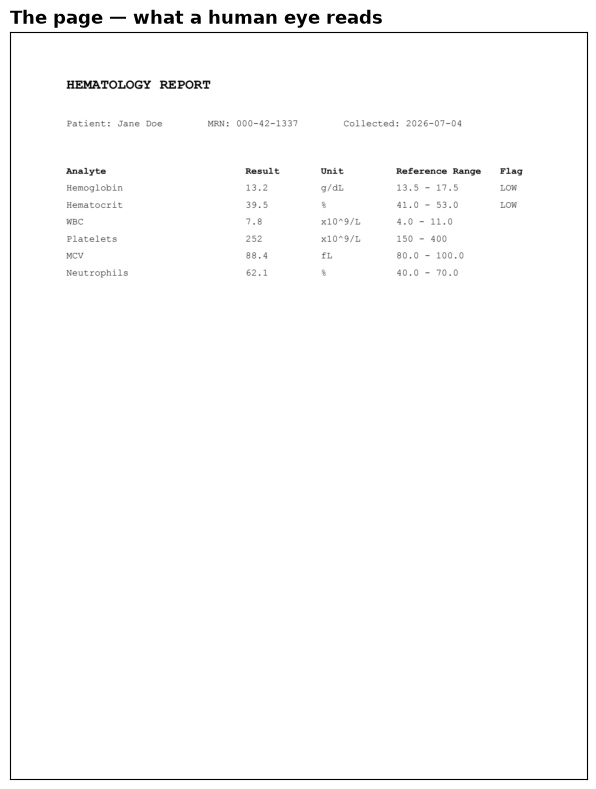

In [1]:
%matplotlib inline
import os, tempfile, bisect
import matplotlib.pyplot as plt

import etkl_demo_data as data          # synthetic lab-report PDF
import etkl_viz as viz                 # plotting helpers (not the pipeline)
from iladub.etkl import extract_words, text_lines, detect_bands, infer_leaf_grid

# Build a synthetic lab report and render page 0 (points -> pixels at 150 DPI)
pdf = os.path.join(tempfile.mkdtemp(), "report.pdf")
truth = data.lab_report_pdf(pdf)
img, scale = viz.render_page(pdf, dpi=150)
viz.show_page(img)
plt.show()

## Step 1 · `geometry` — measure the page in points

`extract_words` reads the PDF text layer via **pdfplumber**, returning each word with a bounding box in
**PDF points** (device-independent — resolution can't move them). This is pure *measurement*: nothing is
interpreted yet. Every fact the compiler emits will cite one of these boxes (provenance-to-page).

53 words; e.g. 'HEMATOLOGY' at x0=60.0, top=47.9 pt


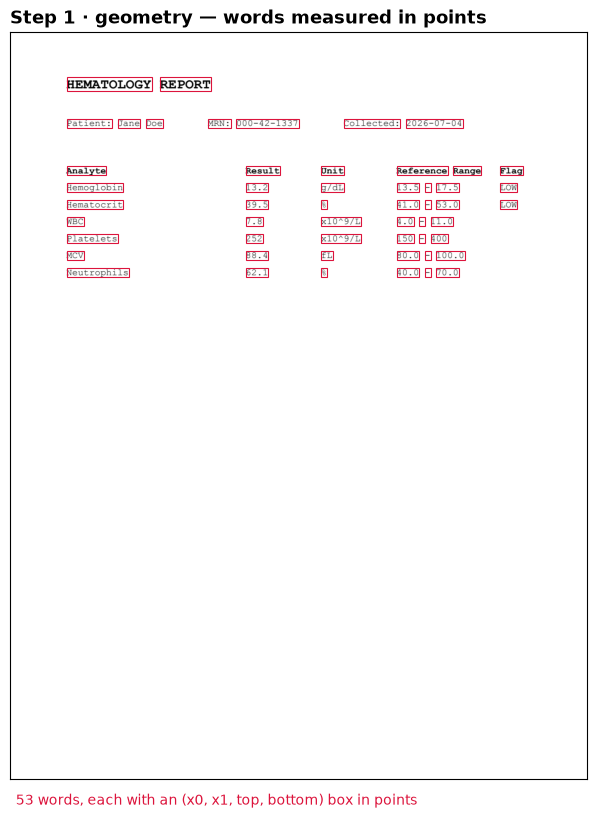

In [2]:
words = extract_words(pdf)
print(f"{len(words)} words; e.g. {words[0].text!r} at x0={words[0].x0:.1f}, top={words[0].top:.1f} pt")
viz.draw_words(img, scale, words)
plt.show()

## Steps 2–3 · `text_lines` + `detect_bands` — layout from vertical whitespace

`text_lines` groups words whose tops align into rows. `detect_bands` then splits the rows into **bands**
wherever the vertical gap jumps above the local norm — the *layout parse*. The side profile shows ink-per-row:
**blank gaps separate the bands**. Here: a title band, a patient/meta band, and the table band.

9 lines -> 3 bands with line counts [1, 1, 7]


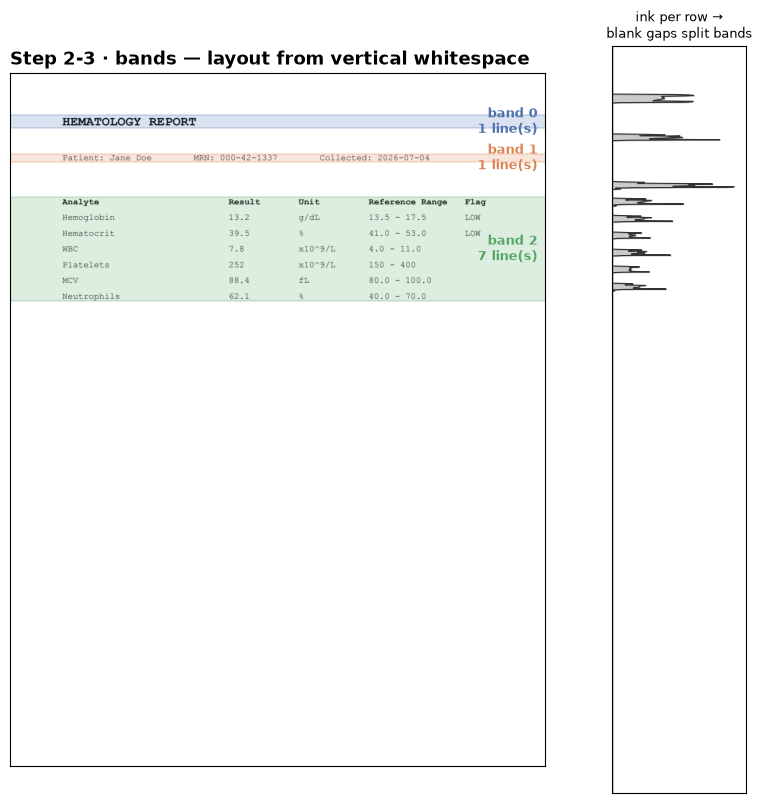

In [3]:
lines = text_lines(words)
bands = detect_bands(lines)
print(f"{len(lines)} lines -> {len(bands)} bands with line counts {[len(b.lines) for b in bands]}")
viz.draw_bands(img, scale, bands)
plt.show()

## Step 4 · `infer_leaf_grid` — the column grid from vertical whitespace

Within the table band, `infer_leaf_grid` computes, for each x-position, the **fraction of rows that are blank**
there. A run that is blank on ~every row is a **gutter** — a true column separator (bottom panel). The gutter
centers become the **leaf-column boundaries** (green lines). Crucially this is measured **globally over the
whole band**, so text that wanders inside a cell can't fake a column, and cosmetic spacing is irrelevant.

The grid also reports a **confidence** from the row-sample size — the hook the later `dec` layer uses to decide
when to trust a reading vs. escalate.

ncols=5  pitch=119pt  confidence=1.00
boundaries (pt): [60.0, 188.0, 308.0, 391.0, 510.0, 544.0]


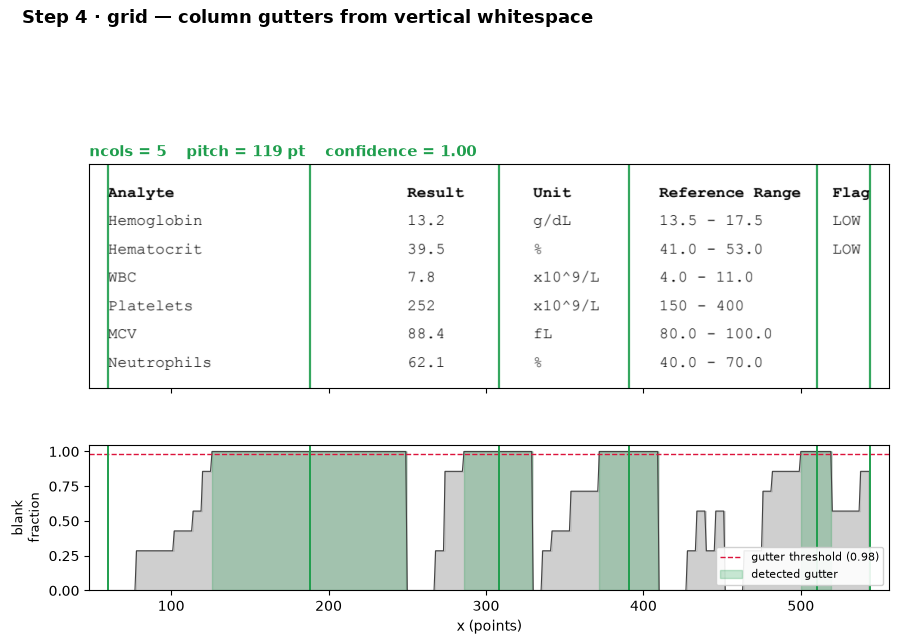

In [4]:
table = bands[-1]
grid = infer_leaf_grid(table)
print(f"ncols={grid.ncols}  pitch={grid.pitch:.0f}pt  confidence={grid.confidence:.2f}")
print("boundaries (pt):", [round(b, 1) for b in grid.boundaries])
viz.draw_grid(img, scale, table, grid)
plt.show()

## The structure, made explicit

From an "unstructured" PDF we now hold an explicit, checkable structure: bands, a column grid, and — the
bridge to increment **1b** — a first mapping of each header word to the leaf column it sits in (by *which
gutters it crosses*). 1b turns that into the nested **header tree** and adds the validator + `dec` verdict;
the model only ever enters for the **residue** the geometry can't decide. Everything below was produced with
**zero model calls**.

In [5]:
for i, b in enumerate(bands):
    print(f"band {i}: {len(b.lines)} line(s), y {b.top:.0f}-{b.bottom:.0f} pt")
print(f"\ntable: {grid.ncols} leaf columns, confidence {grid.confidence:.2f}")
print("header word -> leaf column (preview of 1b's snapping):")
for w in table.lines[0].words:
    col = bisect.bisect_right(grid.boundaries, w.x0) - 1
    print(f"  {w.text:<18} -> column {col}")

band 0: 1 line(s), y 48-63 pt
band 1: 1 line(s), y 92-102 pt
band 2: 7 line(s), y 142-260 pt

table: 5 leaf columns, confidence 1.00
header word -> leaf column (preview of 1b's snapping):
  Analyte            -> column 0
  Result             -> column 1
  Unit               -> column 2
  Reference          -> column 3
  Range              -> column 3
  Flag               -> column 4
